---

<div align="center">
  <img src="https://raw.githubusercontent.com/devicons/devicon/master/icons/python/python-original.svg" width="80"/>
</div>

<h1 align="center">GenAI & Advanced Nets: Fine-Tuning de Transformadores para Classificação de Sentimentos</h1>

<h3 align="center">PhD. Julles Mitoura</h3>

<div align="center">
  <img src="https://img.shields.io/badge/Python-3776AB?style=for-the-badge&logo=python&logoColor=white"/>
  <img src="https://img.shields.io/badge/Jupyter-F37626?style=for-the-badge&logo=jupyter&logoColor=white"/>
  <img src="https://img.shields.io/badge/HuggingFace-FFD21E?style=for-the-badge&logo=huggingface&logoColor=black"/>
</div>

---

In [1]:
# Obs: se você não estiver utilizando um ambiente virtual, instale as bibliotecas conforme se apresenta abaixo
# %pip install -q -r requirements.txt

# pip é o gerenciador de pacotes do Python. Pense nele como o instalador oficial de libs Python.
# no notebook, usar %pip ... é ideal porque instala no mesmo ambiente do kernel em uso.

# -q: quiet
# -r: requirement file, indica ao pip para instalar os pacotes listados no arquivo requirements.txt

---

<div align="center">

## <span style="color:#1E90FF;">Modelo DistilBERT</span>

</div>

Neste notebook aplicamos **fine-tuning** sobre o modelo **DistilBERT** para classificar sentimentos nas mesmas **6 classes** dos notebooks anteriores: *anger*, *fear*, *joy*, *love*, *sadness* e *surprise*.

O **DistilBERT** (*Distilled BERT*) é uma versão compacta do BERT original, obtida por meio de *knowledge distillation* — um processo em que um modelo menor (aluno) é treinado para imitar o comportamento de um modelo maior (professor). O resultado é um modelo com **40% menos parâmetros**, **60% mais rápido** que o BERT-base, mas que retém **97% da sua capacidade** em benchmarks de PLN.

| Característica | BERT-base | DistilBERT |
|----------------|-----------|------------|
| Parâmetros | ~110M | ~66M |
| Camadas Transformer | 12 | 6 |
| Dimensão oculta | 768 | 768 |
| Cabeças de atenção | 12 | 12 |

**Por que não usar spaCy aqui?** Diferente dos modelos FCNN e BiLSTM, o DistilBERT recebe o **texto bruto** (sem lematização nem remoção de stopwords). Seu tokenizador de subpalavras (*WordPiece*), pré-treinado sobre bilhões de tokens, converte o texto em *tokens* preservando informações morfológicas e contextuais que o pré-processamento manual eliminaria.

A estratégia de fine-tuning consiste em inicializar com os pesos pré-treinados e adicionar uma camada de classificação sobre o token `[CLS]`, ajustando todos os parâmetros do modelo por algumas épocas sobre o dataset de destino.

In [2]:
# imports
import warnings
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from datasets import Dataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
)

warnings.filterwarnings('ignore')

# fixando a seed para garantir reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# verifica o device disponível (CUDA, MPS para Apple Silicon, ou CPU)
DEVICE = (
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f'Device: {DEVICE}')
print(f'PyTorch : {torch.__version__}')

/Users/mitoura/Desktop/FIAP/Materiais/GenerativeAI/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps
PyTorch : 2.10.0


---

<div align="center">

## <span style="color:#1E90FF;">Tratamento de Dados</span>

</div>

O pipeline de preparação dos dados para o DistilBERT é mais simples do que nos modelos anteriores, justamente porque a normalização textual é responsabilidade do tokenizador pré-treinado. As operações realizadas são:

- **Carga dos dados**: leitura dos mesmos arquivos de treino e teste usados nos notebooks anteriores;
- **Análise exploratória**: visualização da distribuição das classes;
- **Separação treino/validação**: divisão estratificada para preservar a proporção entre as classes;
- **Codificação dos rótulos**: transformação dos rótulos textuais em identificadores numéricos.

> **Nota:** não aplicamos lematização nem remoção de stopwords. O tokenizador WordPiece do DistilBERT foi pré-treinado sobre texto natural e extrai informação semântica que o pré-processamento manual eliminaria.

In [3]:
def load_dataset(path: str) -> pd.DataFrame:
    """
    Lê o dataset separado por ';' dividindo sempre pelo ÚLTIMO ponto e vírgula,
    garantindo que textos que contenham ';' sejam lidos corretamente.
    Formato esperado por linha:  texto;sentimento
    """
    records = []
    with open(path, encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            idx = line.rfind(';')
            records.append({'texto': line[:idx], 'sentimento': line[idx + 1:]})
    return pd.DataFrame(records)

# carga dos dados
train_path = 'dataset/data_train.txt'
test_path  = 'dataset/data_test.txt'

df_train = load_dataset(train_path)
df_test  = load_dataset(test_path)

print('Shape treino:', df_train.shape)
print('Shape teste :', df_test.shape)
print('\nClasses no treino:', sorted(df_train['sentimento'].unique()))
print('Classes no teste :', sorted(df_test['sentimento'].unique()))

display(df_train.head(3))

Shape treino: (16000, 2)
Shape teste : (2000, 2)

Classes no treino: ['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']
Classes no teste : ['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']


,texto,sentimento
0,i am feeling completely overwhelmed i have two...,fear
1,i have the feeling she was amused and delighted,joy
2,i was able to help chai lifeline with your sup...,joy


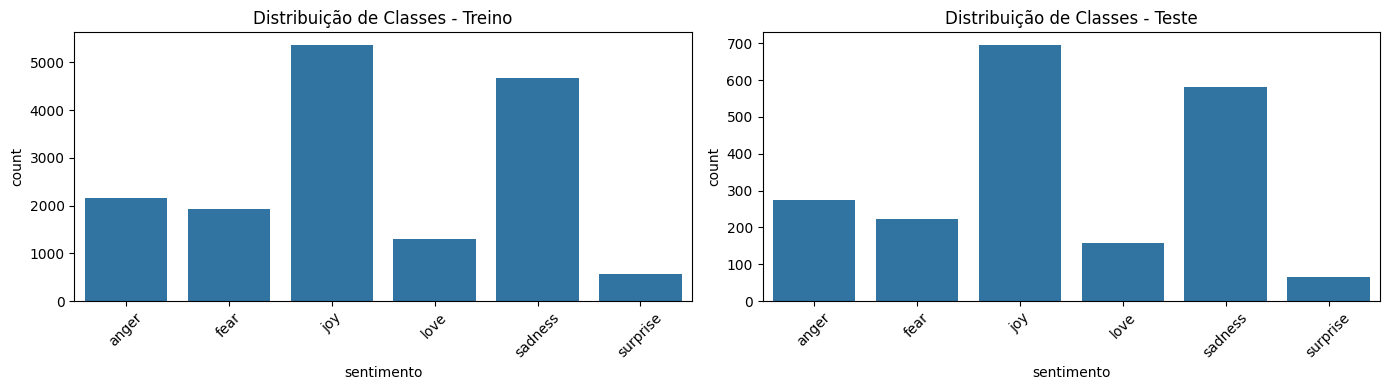

In [4]:
# distribuição das classes nos conjuntos de treino e teste
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.countplot(data=df_train, x='sentimento', order=sorted(df_train['sentimento'].unique()), ax=axes[0])
axes[0].set_title('Distribuição de Classes - Treino')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(data=df_test, x='sentimento', order=sorted(df_test['sentimento'].unique()), ax=axes[1])
axes[1].set_title('Distribuição de Classes - Teste')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [5]:
# separação treino/validação e codificação dos rótulos
df_train_inner, df_valid = train_test_split(
    df_train,
    test_size=0.2,
    random_state=SEED,
    stratify=df_train['sentimento'],
)

le_global = LabelEncoder()
le_global.fit(df_train['sentimento'])

# adicionando coluna de id numérico do rótulo (padrão 'labels' exigido pelo Trainer)
df_train_inner = df_train_inner.copy()
df_valid       = df_valid.copy()
df_test_sf     = df_test.copy()

df_train_inner['labels'] = le_global.transform(df_train_inner['sentimento'])
df_valid['labels']       = le_global.transform(df_valid['sentimento'])
df_test_sf['labels']     = le_global.transform(df_test_sf['sentimento'])

class_names = list(le_global.classes_)
num_classes = len(class_names)

print('Classes:', class_names)
print(f'Treino  : {len(df_train_inner)} | Validação: {len(df_valid)} | Teste: {len(df_test_sf)}')

Classes: ['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']
Treino  : 12800 | Validação: 3200 | Teste: 2000


---

<div align="center">

## <span style="color:#1E90FF;">Treinamento do Modelo</span>

</div>

Esta etapa cobre quatro fases encadeadas:

**1. Tokenização** — o `AutoTokenizer` carrega o vocabulário WordPiece do DistilBERT e converte cada texto em uma sequência de *input_ids* (índices inteiros), *attention_mask* (máscara de atenção que ignora tokens de padding) e, opcionalmente, *token_type_ids*. O padding é aplicado dinamicamente a cada batch pelo `DataCollatorWithPadding`, o que é mais eficiente do que preencher todas as sequências até o comprimento máximo.

**2. Datasets HuggingFace** — os DataFrames pandas são convertidos para o formato `Dataset` da biblioteca `datasets`, que oferece caching, processamento paralelo e integração nativa com o `Trainer`.

**3. Arquitetura** — o `AutoModelForSequenceClassification` carrega os pesos pré-treinados do DistilBERT e adiciona automaticamente uma **cabeça de classificação**: uma camada densa sobre o vetor `[CLS]` com `num_labels` saídas.

| Componente | Descrição |
|------------|-----------|
| Corpo pré-treinado | 6 camadas Transformer com atenção multi-cabeça (12 cabeças) |
| Pooling | Representação do token `[CLS]` (primeiro token da sequência) |
| Cabeça de classificação | `Linear(768 → num_labels)` + `Dropout` |

**4. Treinamento** — o `Trainer` gerencia o loop de treino, a avaliação por época, o checkpointing e a restauração do melhor modelo. Os hiperparâmetros seguem as boas práticas para fine-tuning de BERT: taxa de aprendizado baixa (`2e-5`), poucas épocas (3–5) e *weight decay* para regularização.

In [6]:
# ── Hiperparâmetros ───────────────────────────────────────────────────────────

MODEL_NAME = 'distilbert-base-uncased'
MAX_LEN    = 128
EPOCHS     = 10
BATCH      = 16
LR         = 2e-5

# ── Tokenização ───────────────────────────────────────────────────────────────

# carrega o tokenizador WordPiece do DistilBERT
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(batch):
    # truncation=True: limita ao MAX_LEN tokens
    # padding=False: padding dinâmico será aplicado pelo DataCollatorWithPadding
    return tokenizer(batch['texto'], truncation=True, max_length=MAX_LEN, padding=False)

# ── Criação dos Datasets HuggingFace ─────────────────────────────────────────

# converte os DataFrames pandas para o formato Dataset do HuggingFace
ds_train = Dataset.from_pandas(df_train_inner[['texto', 'labels']], preserve_index=False)
ds_valid = Dataset.from_pandas(df_valid[['texto', 'labels']],       preserve_index=False)
ds_test  = Dataset.from_pandas(df_test_sf[['texto', 'labels']],     preserve_index=False)

# aplica a tokenização em batches (mais eficiente que sample a sample)
ds_train = ds_train.map(tokenize_function, batched=True)
ds_valid = ds_valid.map(tokenize_function, batched=True)
ds_test  = ds_test.map(tokenize_function,  batched=True)

print(f'Treino   : {len(ds_train)} amostras | features: {ds_train.features}')
print(f'Validação: {len(ds_valid)} amostras')
print(f'Teste    : {len(ds_test)}  amostras')

# ── Arquitetura ───────────────────────────────────────────────────────────────

# carrega o modelo pré-treinado com cabeça de classificação para num_classes saídas
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_classes,
    id2label={i: lbl for i, lbl in enumerate(class_names)},
    label2id={lbl: i for i, lbl in enumerate(class_names)},
)

n_params_total      = sum(p.numel() for p in model.parameters())
n_params_trainable  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nModelo             : {MODEL_NAME}')
print(f'Parâmetros totais  : {n_params_total:,}')
print(f'Parâmetros treináveis: {n_params_trainable:,}')

# ── Configuração do Treino ────────────────────────────────────────────────────

def compute_metrics(eval_pred):
    """Calcula acurácia e F1-macro a cada avaliação durante o treino."""
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    return {
        'accuracy': float(accuracy_score(labels, preds)),
        'f1_macro': float(f1_score(labels, preds, average='macro', zero_division=0)),
    }

training_args = TrainingArguments(
    output_dir='models/checkpoints_distilbert',
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH,
    per_device_eval_batch_size=BATCH,
    learning_rate=LR,
    weight_decay=0.01,             # regularização L2 nos pesos (exceto biases)
    eval_strategy='epoch',         # avalia ao final de cada época
    save_strategy='epoch',         # salva checkpoint ao final de cada época
    load_best_model_at_end=True,   # restaura o melhor checkpoint ao fim do treino
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    logging_steps=50,
    report_to='none',              # desativa relatórios externos (WandB, etc.)
    seed=SEED,
)

# DataCollatorWithPadding: aplica padding dinâmico ao batch atual (mais eficiente)
collator = DataCollatorWithPadding(tokenizer=tokenizer)

# ── Treinamento ───────────────────────────────────────────────────────────────

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=ds_train,
    eval_dataset=ds_valid,
    tokenizer=tokenizer,
    data_collator=collator,
    compute_metrics=compute_metrics,
)

trainer.train()

Map: 100%|██████████| 2000/2000 [00:00<00:00, 94637.89 examples/s]


Treino   : 12800 amostras | features: {'texto': Value('large_string'), 'labels': Value('int64'), 'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8'))}
Validação: 3200 amostras
Teste    : 2000  amostras


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Modelo             : distilbert-base-uncased
Parâmetros totais  : 66,958,086
Parâmetros treináveis: 66,958,086


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.226800,0.204786,0.925625,0.889144
2,0.163500,0.189916,0.931875,0.897434
3,0.141200,0.190843,0.930000,0.897709
4,0.081700,0.214464,0.928438,0.889452
5,0.071000,0.270114,0.929688,0.891440
6,0.026200,0.313393,0.930000,0.892767
7,0.025400,0.372133,0.929375,0.895307
8,0.026400,0.385736,0.928438,0.890927
9,0.014000,0.390767,0.925312,0.887840
10,0.011100,0.396329,0.925937,0.887567


TrainOutput(global_step=8000, training_loss=0.11312980376463383, metrics={'train_runtime': 737.5029, 'train_samples_per_second': 173.559, 'train_steps_per_second': 10.847, 'total_flos': 1551411529017984.0, 'train_loss': 0.11312980376463383, 'epoch': 10.0})

---

<div align="center">

## <span style="color:#1E90FF;">Avaliação do Modelo</span>

</div>

Com o fine-tuning concluído, avaliamos o DistilBERT no conjunto de teste — que não participou nem do treino nem da seleção do melhor checkpoint. As mesmas métricas dos notebooks anteriores são calculadas para permitir comparação direta:

- **Acurácia geral**: proporção de amostras classificadas corretamente;
- **F1-Score Macro**: média do F1 por classe sem ponderação;
- **F1-Score Weighted**: média do F1 ponderada pelo suporte de cada classe;
- **Relatório de classificação**: precisão, recall e F1 por classe;
- **Curvas de aprendizado**: loss de treino (por step) e métricas de validação (por época), extraídas do log interno do `Trainer`;
- **Matriz de confusão**: visualização dos erros de predição entre classes.

=== Resultado: DistilBERT ===
Accuracy geral    : 0.9295
F1 Macro          : 0.8831
F1 Weighted       : 0.9297

              precision    recall  f1-score   support

       anger       0.96      0.90      0.93       275
        fear       0.86      0.94      0.90       224
         joy       0.96      0.93      0.95       695
        love       0.77      0.93      0.84       159
     sadness       0.97      0.97      0.97       581
    surprise       0.81      0.64      0.71        66

    accuracy                           0.93      2000
   macro avg       0.89      0.88      0.88      2000
weighted avg       0.93      0.93      0.93      2000



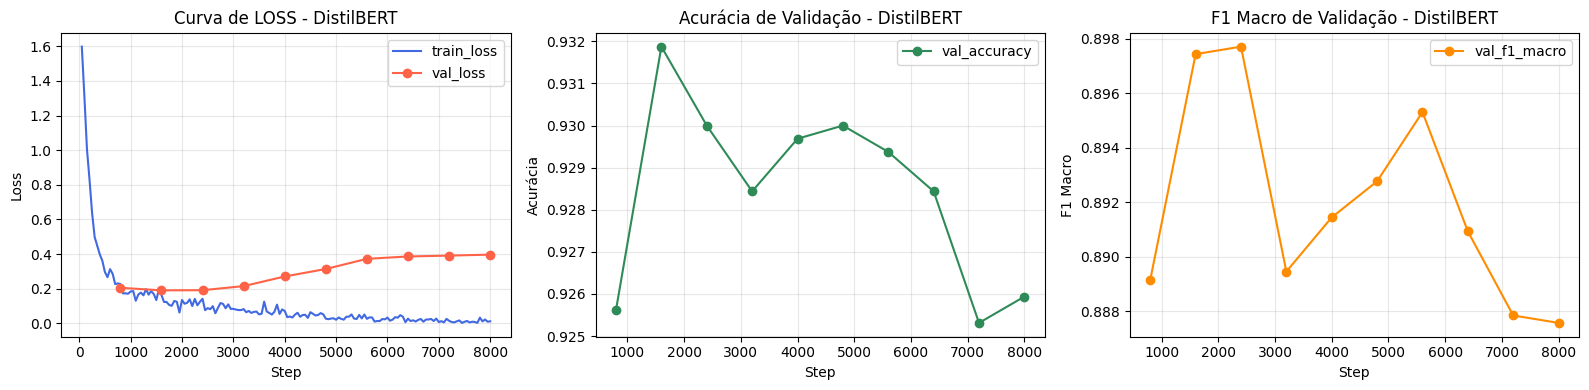

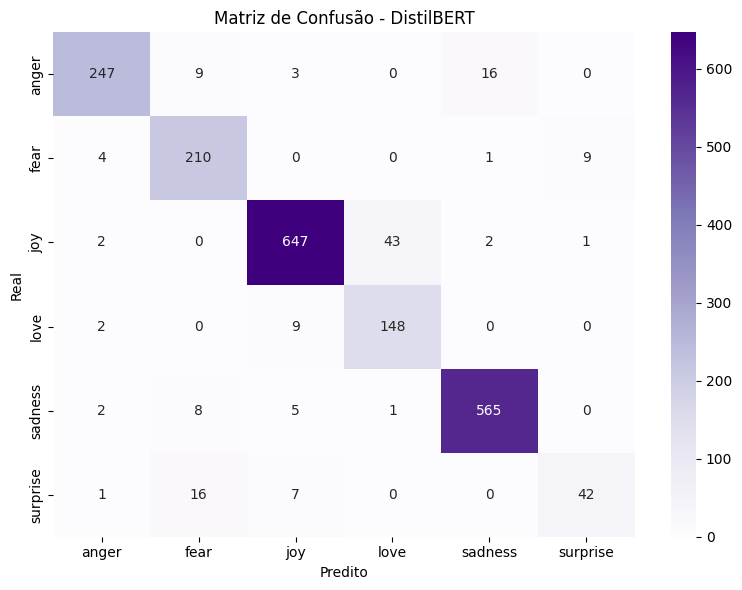

In [7]:
# predições no conjunto de teste
preds_output = trainer.predict(ds_test)
pred_ids = preds_output.predictions.argmax(axis=-1)
true_ids = np.array(df_test_sf['labels'].tolist())

y_true_lbl = le_global.inverse_transform(true_ids)
y_pred_lbl = le_global.inverse_transform(pred_ids)

acc        = accuracy_score(y_true_lbl, y_pred_lbl)
f1_macro   = f1_score(y_true_lbl, y_pred_lbl, average='macro',    zero_division=0)
f1_weighted= f1_score(y_true_lbl, y_pred_lbl, average='weighted', zero_division=0)

# métricas gerais
print('=== Resultado: DistilBERT ===')
print(f'Accuracy geral    : {acc:.4f}')
print(f'F1 Macro          : {f1_macro:.4f}')
print(f'F1 Weighted       : {f1_weighted:.4f}\n')
print(classification_report(y_true_lbl, y_pred_lbl, zero_division=0))

# curvas de aprendizado extraídas do log interno do Trainer
log = trainer.state.log_history

train_steps = [e['step'] for e in log if 'loss' in e and 'eval_loss' not in e]
train_loss  = [e['loss'] for e in log if 'loss' in e and 'eval_loss' not in e]

eval_steps  = [e['step']          for e in log if 'eval_loss' in e]
eval_loss   = [e['eval_loss']     for e in log if 'eval_loss' in e]
eval_acc    = [e.get('eval_accuracy', 0) for e in log if 'eval_loss' in e]
eval_f1     = [e.get('eval_f1_macro', 0) for e in log if 'eval_loss' in e]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(train_steps, train_loss, color='royalblue', linewidth=1.5, label='train_loss')
axes[0].plot(eval_steps,  eval_loss,  color='tomato', linewidth=1.5, marker='o', label='val_loss')
axes[0].set_title('Curva de LOSS - DistilBERT')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(eval_steps, eval_acc, color='seagreen', linewidth=1.5, marker='o', label='val_accuracy')
axes[1].set_title('Acurácia de Validação - DistilBERT')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Acurácia')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(eval_steps, eval_f1, color='darkorange', linewidth=1.5, marker='o', label='val_f1_macro')
axes[2].set_title('F1 Macro de Validação - DistilBERT')
axes[2].set_xlabel('Step')
axes[2].set_ylabel('F1 Macro')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# matriz de confusão
cm = confusion_matrix(y_true_lbl, y_pred_lbl, labels=class_names)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão - DistilBERT')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

---

<div align="center">

## <span style="color:#1E90FF;">Avaliação com Frases Externas</span>

</div>

Para verificar a capacidade de **generalização** do modelo, aplicamos o DistilBERT às mesmas três frases usadas nos notebooks anteriores (FCNN e BiLSTM), permitindo uma **comparação direta** entre as abordagens. Diferente dos modelos anteriores, o DistilBERT recebe o **texto bruto** — sem qualquer pré-processamento — pois seu tokenizador WordPiece realiza essa etapa internamente.

=== Predições: DistilBERT ===

Frase 1: "Today I got my dream job offer after months of waiting. I can barely breathe. I am ralley happy."
  → Classe predita : JOY  (confiança: 99.9%)

Frase 2: "My dog passed away this morning. The house feels empty without him."
  → Classe predita : SADNESS  (confiança: 99.9%)

Frase 3: "They raised the price of my coffee again. Three times in one year!"
  → Classe predita : ANGER  (confiança: 96.9%)



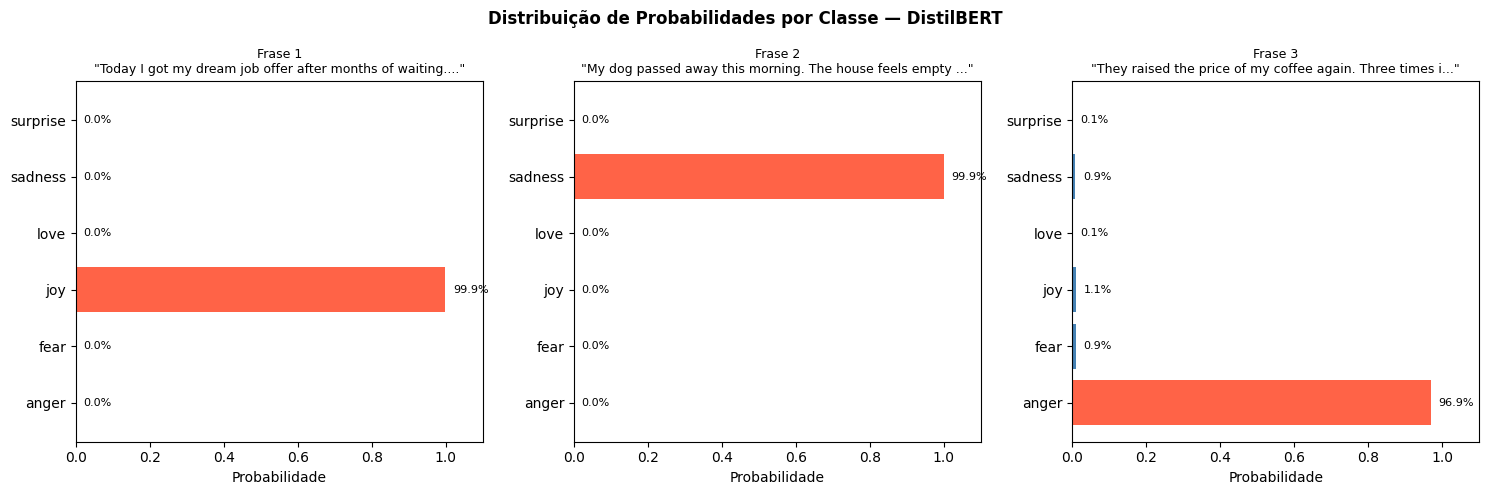

In [8]:
# frases externas — fora do escopo dos dados de treino (texto bruto, sem pré-processamento)
frases_externas = [
    "Today I got my dream job offer after months of waiting. I can barely breathe. I am ralley happy.",
    "My dog passed away this morning. The house feels empty without him.",
    "They raised the price of my coffee again. Three times in one year!",
]

# tokenização com o mesmo tokenizer usado no treino
inputs = tokenizer(
    frases_externas,
    truncation=True,
    max_length=MAX_LEN,
    padding=True,
    return_tensors='pt',
)

# após o treino o modelo pode estar em CUDA/MPS — move os inputs para o mesmo device
device = next(model.parameters()).device
inputs = {k: v.to(device) for k, v in inputs.items()}

# predição: logits → softmax → probabilidades por classe
# .cpu() garante que o tensor retorna para CPU antes de converter para numpy
model.eval()
with torch.no_grad():
    outputs   = model(**inputs)
    probs_ext = torch.softmax(outputs.logits, dim=-1).cpu().numpy()

preds_ext  = probs_ext.argmax(axis=-1)
labels_ext = le_global.inverse_transform(preds_ext)

# resultados textuais
print('=== Predições: DistilBERT ===\n')
for i, (frase, label, prob) in enumerate(zip(frases_externas, labels_ext, probs_ext)):
    print(f'Frase {i + 1}: "{frase}"')
    print(f'  → Classe predita : {label.upper()}  (confiança: {prob.max():.1%})\n')

# visualização: distribuição de probabilidades por classe
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (frase, prob, pred) in enumerate(zip(frases_externas, probs_ext, labels_ext)):
    cores = ['tomato' if c == pred else 'steelblue' for c in class_names]
    bars  = axes[i].barh(class_names, prob, color=cores)
    titulo = f'Frase {i + 1}\n"{frase[:55]}..."' if len(frase) > 55 else f'Frase {i + 1}\n"{frase}"'
    axes[i].set_title(titulo, fontsize=9)
    axes[i].set_xlim(0, 1.1)
    axes[i].set_xlabel('Probabilidade')
    for bar, p in zip(bars, prob):
        axes[i].text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
                     f'{p:.1%}', va='center', fontsize=8)

plt.suptitle('Distribuição de Probabilidades por Classe — DistilBERT', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---

<div align="center">

## <span style="color:#1E90FF;">Salvamento do Modelo</span>

</div>

Para reutilizar o modelo em produção ou em notebooks futuros, salvamos **todos os artefatos do pipeline de inferência**. O ecossistema HuggingFace utiliza o formato `save_pretrained`, que persiste os pesos, a configuração da arquitetura e o tokenizador em um único diretório. O `LabelEncoder` é salvo separadamente com `pickle`.

| Artefato | Destino | Conteúdo |
|----------|---------|----------|
| Modelo fine-tunado | `models/distilbert_sentiment/` | Pesos (`pytorch_model.bin` / `model.safetensors`), `config.json` |
| Tokenizador | `models/distilbert_sentiment/` | Vocabulário WordPiece, parâmetros de tokenização |
| LabelEncoder | `models/distilbert_label_encoder.pkl` | Mapeamento id ↔ rótulo |

Para recarregar e usar o modelo:

```python
import pickle
from transformers import pipeline

pipe = pipeline(
    'text-classification',
    model='models/distilbert_sentiment',
    tokenizer='models/distilbert_sentiment',
)

le = pickle.load(open('models/distilbert_label_encoder.pkl', 'rb'))

resultado = pipe("I feel so happy today!")
print(resultado)  # [{'label': 'joy', 'score': 0.97}]
```

In [9]:
import pickle
import os

os.makedirs('models', exist_ok=True)

# salva o modelo fine-tunado e o tokenizador no formato HuggingFace (save_pretrained)
# gera: config.json, model.safetensors (ou pytorch_model.bin), tokenizer_config.json, vocab.txt, etc.
SAVE_DIR = 'models/distilbert_sentiment'

trainer.save_model(SAVE_DIR)       # salva o melhor checkpoint restaurado pelo load_best_model_at_end
tokenizer.save_pretrained(SAVE_DIR)

# salva o LabelEncoder (mapeamento id ↔ rótulo) necessário para interpretar as predições
with open('models/distilbert_label_encoder.pkl', 'wb') as f:
    pickle.dump(le_global, f)

print(f'Modelo e tokenizador salvos em: {SAVE_DIR}/')
print('\nConteúdo do diretório:')
for fname in sorted(os.listdir(SAVE_DIR)):
    size = os.path.getsize(f'{SAVE_DIR}/{fname}') / 1024
    print(f'  {fname:45s}  {size:8.1f} KB')

print(f'\n  distilbert_label_encoder.pkl          '
      f'  {os.path.getsize("models/distilbert_label_encoder.pkl") / 1024:8.1f} KB')

Modelo e tokenizador salvos em: models/distilbert_sentiment/

Conteúdo do diretório:
  config.json                                         0.8 KB
  model.safetensors                              261567.3 KB
  special_tokens_map.json                             0.1 KB
  tokenizer.json                                    695.0 KB
  tokenizer_config.json                               1.2 KB
  training_args.bin                                   5.6 KB
  vocab.txt                                         226.1 KB

  distilbert_label_encoder.pkl                 0.3 KB
